In [8]:
!gdown 13vTkYO5hTI5vjpQosk2P5rMj2QvUUvNu

375.39s - pydevd: Sending message related to process being replaced timed-out after 5 seconds


/Users/nithinys/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(
Downloading...
From: https://drive.google.com/uc?id=13vTkYO5hTI5vjpQosk2P5rMj2QvUUvNu
To: /Users/nithinys/GithubRepos/ml-ai-genai-ds-journal/module05-unsupervised/kmeans/Online_Retail.csv
100%|██████████████████████████████████████| 46.1M/46.1M [00:09<00:00, 4.80MB/s]


In [9]:
#imprting libraries
import pandas as pd 
import numpy as np

#for visualization
import matplotlib.pyplot as plt 
import seaborn as sns
%matplotlib inline

#to scale our data 
from sklearn.preprocessing import StandardScaler

#to perform kmeans clustering 
from sklearn.cluster import KMeans 





In [10]:
retail = pd.read_csv("Online_Retail.csv" , sep = ",", encoding = "ISO-8859-1", header = 0, )

In [11]:
retail.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,01-12-2010 08:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,01-12-2010 08:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,01-12-2010 08:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,01-12-2010 08:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,01-12-2010 08:26,3.39,17850.0,United Kingdom


In [12]:
#parse data 
retail['InvoiceDate'] = pd.to_datetime(retail['InvoiceDate'], format= '%d-%m-%Y %H:%M')

In [13]:
retail.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [17]:
#Na handling 

retail.isnull().values.any()
retail.isnull().sum()
retail.isnull().sum()*100/retail.shape[0]

InvoiceNo       0.000000
StockCode       0.000000
Description     0.268311
Quantity        0.000000
InvoiceDate     0.000000
UnitPrice       0.000000
CustomerID     24.926694
Country         0.000000
dtype: float64

In [18]:
order_wise = retail.dropna()

In [20]:
order_wise.isnull().sum()


InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64

In [21]:
#RFM implementation

amount = pd.DataFrame(order_wise.Quantity * order_wise.UnitPrice, columns = ['Amount'])
amount.head()

,Amount
0,15.30
1,20.34
2,22.00
3,20.34
4,20.34


In [35]:
if 'Amount' in order_wise.columns:
    order_wise = order_wise.drop(columns=['Amount'])

# merging amounts in order of
order_wise = pd.concat(objs = [order_wise, amount], axis = 1, ignore_index = False)

# Monetary function
# finding total amount spent per customer
monetary = order_wise.groupby("CustomerID").Amount.sum()
monetary = monetary.reset_index()
monetary.head()

,CustomerID,Amount
0,12346.0,0.00
1,12347.0,4310.00
2,12348.0,1797.24
3,12349.0,1757.55
4,12350.0,334.40


In [37]:
k = order_wise.groupby("CustomerID").InvoiceNo.count()
k = pd.DataFrame(k)
k = k.reset_index()
k.columns = ['CustomerID', 'Frequency']
k.head()


,CustomerID,Frequency
0,12346.0,2
1,12347.0,182
2,12348.0,31
3,12349.0,73
4,12350.0,17


In [38]:
master = monetary.merge(k, on = 'CustomerID', how = 'inner')
master.head()

,CustomerID,Amount,Frequency
0,12346.0,0.00,2
1,12347.0,4310.00,182
2,12348.0,1797.24,31
3,12349.0,1757.55,73
4,12350.0,334.40,17


In [39]:
recency = order_wise[['CustomerID', 'InvoiceDate']]
maximum = max(recency.InvoiceDate)
recency

,CustomerID,InvoiceDate
0,17850.0,2010-12-01 08:26:00
1,17850.0,2010-12-01 08:26:00
2,17850.0,2010-12-01 08:26:00
3,17850.0,2010-12-01 08:26:00
4,17850.0,2010-12-01 08:26:00
...,...,...
541904,12680.0,2011-12-09 12:50:00
541905,12680.0,2011-12-09 12:50:00
541906,12680.0,2011-12-09 12:50:00
541907,12680.0,2011-12-09 12:50:00


In [40]:
maximum 

Timestamp('2011-12-09 12:50:00')

In [45]:
# generating recency function

# filtering data for customerid and invoice_date
recency  = order_wise[['CustomerID', 'InvoiceDate']]

# finding max data
maximum = max(recency.InvoiceDate)

# adding one more day to the max data, so that the max date will have 1 as the difference and not zero.
maximum = maximum + pd.DateOffset(days=1)
recency['diff'] = maximum - recency.InvoiceDate
recency.head()

/var/folders/96/pzp77pgj2jngfzbn1nyzz6w80000gn/T/ipykernel_1257/1468527610.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  recency['diff'] = maximum - recency.InvoiceDate


,CustomerID,InvoiceDate,diff
0,17850.0,2010-12-01 08:26:00,374 days 04:24:00
1,17850.0,2010-12-01 08:26:00,374 days 04:24:00
2,17850.0,2010-12-01 08:26:00,374 days 04:24:00
3,17850.0,2010-12-01 08:26:00,374 days 04:24:00
4,17850.0,2010-12-01 08:26:00,374 days 04:24:00


In [48]:
a = recency.groupby("CustomerID")
a['diff'].min()


CustomerID
12346.0   326 days 02:33:00
12347.0     2 days 20:58:00
12348.0    75 days 23:37:00
12349.0    19 days 02:59:00
12350.0   310 days 20:49:00
                 ...       
18280.0   278 days 02:58:00
18281.0   181 days 01:57:00
18282.0     8 days 01:07:00
18283.0     4 days 00:48:00
18287.0    43 days 03:21:00
Name: diff, Length: 4372, dtype: timedelta64[ns]

In [49]:
df = pd.DataFrame(recency.groupby("CustomerID")['diff'].min())
df = df.reset_index()
df.columns = ['CustomerID', 'Recency']
df.head()

,CustomerID,Recency
0,12346.0,326 days 02:33:00
1,12347.0,2 days 20:58:00
2,12348.0,75 days 23:37:00
3,12349.0,19 days 02:59:00
4,12350.0,310 days 20:49:00


In [54]:
RFM = k.merge(monetary, on = 'CustomerID', how = 'inner')
RFM = RFM.merge(df, on = 'CustomerID', how = 'inner')
RFM.head()

,CustomerID,Frequency,Amount,Recency
0,12346.0,2,0.00,326 days 02:33:00
1,12347.0,182,4310.00,2 days 20:58:00
2,12348.0,31,1797.24,75 days 23:37:00
3,12349.0,73,1757.55,19 days 02:59:00
4,12350.0,17,334.40,310 days 20:49:00


{'whiskers': [<matplotlib.lines.Line2D at 0x12e4f08e0>,
 'caps': [<matplotlib.lines.Line2D at 0x12e4f0dc0>,
 'boxes': [<matplotlib.lines.Line2D at 0x12e4f05e0>],
 'medians': [<matplotlib.lines.Line2D at 0x12e69d340>],
 'fliers': [<matplotlib.lines.Line2D at 0x12e69d5e0>],
 'means': []}

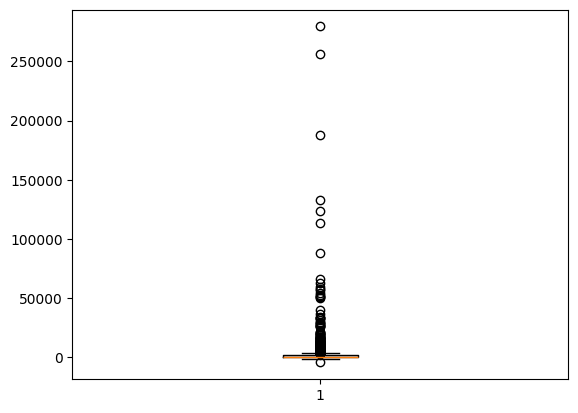

In [55]:
plt.boxplot(RFM.Amount)

In [56]:
Q1 = RFM.Amount.quantile(0.25)
Q3 = RFM.Amount.quantile(0.75)
IQR = Q3 - Q1
RFM = RFM[~((RFM.Amount < (Q1 - 1.5 * IQR)) | (RFM.Amount > (Q3 + 1.5 * IQR)))]

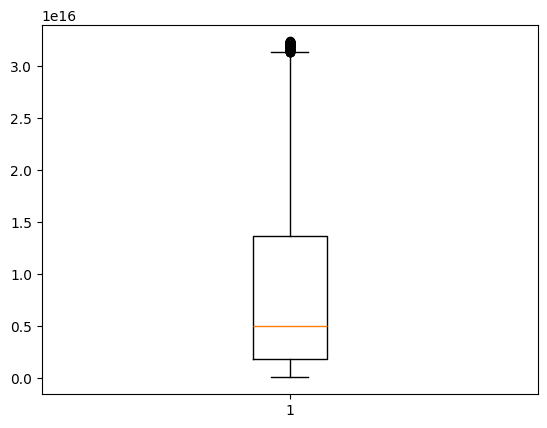

In [58]:
plt.boxplot(RFM.Recency)
Q1 = RFM.Recency.quantile(0.25)
Q3 = RFM.Recency.quantile(0.75)
IQR = Q3 - Q1
RFM = RFM[~((RFM.Recency < (Q1 - 1.5 * IQR)) | (RFM.Recency > (Q3 + 1.5 * IQR)))]

In [60]:
RFM_norm1 = RFM.drop("CustomerID", axis=1)

In [61]:
RFM_norm1.head()

,Frequency,Amount,Recency
0,2,0.00,326 days 02:33:00
2,31,1797.24,75 days 23:37:00
3,73,1757.55,19 days 02:59:00
4,17,334.40,310 days 20:49:00
5,95,1545.41,36 days 22:13:00


In [62]:
RFM_norm1['Recency'] = RFM_norm1['Recency'].dt.days

In [68]:
from sklearn.preprocessing import StandardScaler
standard_scaler = StandardScaler()
RFM_norm1 = standard_scaler.fit_transform(RFM_norm1)

In [64]:
RFM_norm1 = pd.DataFrame(RFM_norm1)
RFM_norm1.columns = ['Frequency', 'Amount', 'Recency']
RFM_norm1.head()

,Frequency,Amount,Recency
0,-0.783868,-1.065957,2.443383
1,-0.410310,1.137317,-0.193213
2,0.130704,1.088660,-0.781457
3,-0.590649,-0.656009,2.275313
4,0.414093,0.828593,-0.602883


/Users/nithinys/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/nithinys/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/nithinys/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/nithinys/Library/Python/3.9/lib/python/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: divide by zero encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/Users/nithinys/Library/Python/3.9/lib/python/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: overflow encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/Users/nithinys/Library/Python/3.9/lib/python/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: invalid value encountered in matmul
  current_po

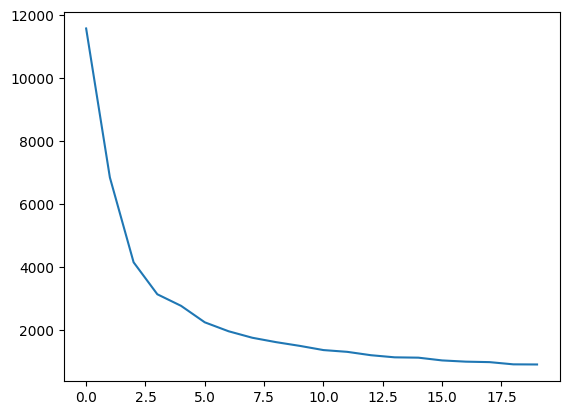

In [69]:
ssd = []
for num_clusters in list(range(1,21)):
    model_clus = KMeans(n_clusters = num_clusters, max_iter=50)
    model_clus.fit(RFM_norm1)
    ssd.append(model_clus.inertia_)

plt.plot(ssd)

In [70]:
model_clus3 = KMeans(n_clusters = 3, max_iter=50)
model_clus3.fit(RFM_norm1)

/Users/nithinys/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/nithinys/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/nithinys/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/nithinys/Library/Python/3.9/lib/python/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: divide by zero encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/Users/nithinys/Library/Python/3.9/lib/python/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: overflow encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/Users/nithinys/Library/Python/3.9/lib/python/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: invalid value encountered in matmul
  current_po

KMeans(max_iter=50, n_clusters=3)

In [71]:
model_clus3.labels_

array([2, 0, 1, ..., 0, 1, 1], dtype=int32)

In [77]:
RFM.index = pd.RangeIndex(len(RFM.index))
RFM_km = pd.concat([RFM, pd.Series(model_clus3.labels_)], axis=1)
RFM_km.columns = ['CustomerID', 'Frequency', 'Amount', 'Recency', 'ClusterID']

RFM_km.Recency = RFM_km.Recency.dt.days
km_clusters_amount =    pd.DataFrame(RFM_km.groupby(["ClusterID"]).Amount.mean())
km_clusters_frequency =     pd.DataFrame(RFM_km.groupby(["ClusterID"]).Frequency.mean())
km_clusters_recency =   pd.DataFrame(RFM_km.groupby(["ClusterID"]).Recency.mean())

In [78]:
df = pd.concat([pd.Series([0,1,2]), km_clusters_amount, km_clusters_frequency, km_clusters_recency], axis=1)
df.columns = ["ClusterID", "Amount_mean", "Frequency_mean", "Recency_mean"]
df.head()

,ClusterID,Amount_mean,Frequency_mean,Recency_mean
0,0,619.016466,42.122881,48.183616
1,1,2198.167400,168.857516,34.592157
2,2,371.715642,24.762590,238.315519


<Axes: xlabel='ClusterID', ylabel='Amount_mean'>

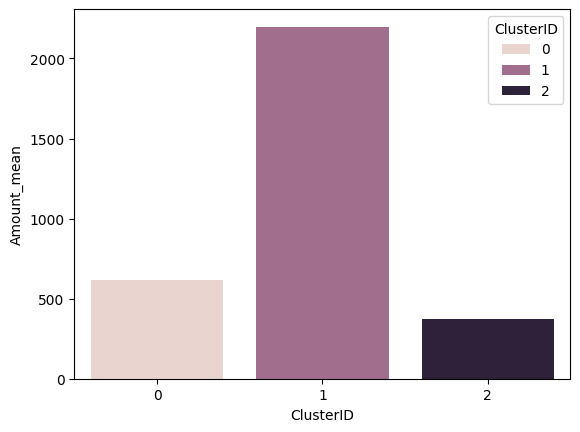

In [79]:
sns.barplot(x=df.ClusterID, y=df.Amount_mean, hue=df.ClusterID)

<Axes: xlabel='ClusterID', ylabel='Frequency_mean'>

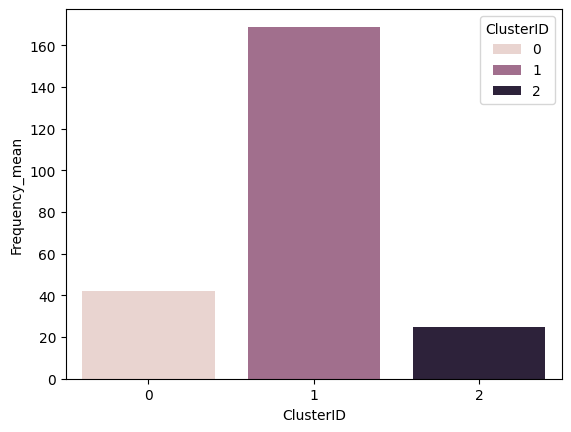

In [76]:
sns.barplot(x=df.ClusterID, y=df.Frequency_mean,hue=df.ClusterID)